In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/amer_sign2.png
/kaggle/input/datasets/datamunge/sign-language-mnist/amer_sign3.png
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/american_sign_language.PNG
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv
/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

2026-04-23 16:14:21.191265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776960861.394504      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776960861.449744      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776960861.882325      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776960861.882363      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776960861.882366      55 computation_placer.cc:177] computation placer alr

In [5]:
import pandas as pd

train_df = pd.read_csv('/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv')

test_df = pd.read_csv('/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (27455, 785)
Test shape: (7172, 785)


Labels shape: (27455,)
Pixels shape: (27455, 784)
Unique classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Total classes: 24


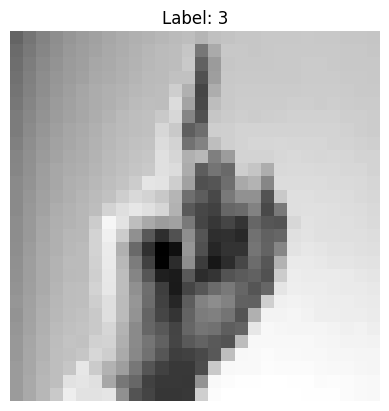

In [9]:
# Separate labels and pixels
labels = train_df['label']
pixels = train_df.drop('label', axis=1)

print("Labels shape:", labels.shape)
print("Pixels shape:", pixels.shape)

# Check unique classes
print("Unique classes:", sorted(labels.unique()))
print("Total classes:", len(labels.unique()))

# Show one image
import matplotlib.pyplot as plt

img = pixels.iloc[0].values.reshape(28, 28)

plt.imshow(img, cmap='gray')
plt.title(f"Label: {labels.iloc[0]}")
plt.axis('off')
plt.show()

In [11]:
# Reshape into 28x28x1
X = pixels.values.reshape(-1, 28, 28, 1)

# Normalize
X = X / 255.0

# FIXED: use 25
y = to_categorical(labels, num_classes=25)

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)

X_train shape: (21964, 28, 28, 1)
X_val shape: (5491, 28, 28, 1)
y_train shape: (21964, 25)


In [12]:
model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    
    Dense(25, activation='softmax')  # 25 because labels go till 24
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776961338.403466      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10


I0000 00:00:1776961392.717905     140 service.cc:152] XLA service 0x7c64d80096c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776961392.717948     140 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776961393.056776     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


 53/344 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0610 - loss: 3.2006

I0000 00:00:1776961395.529253     140 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2574 - loss: 2.5005 - val_accuracy: 0.8700 - val_loss: 0.5797
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8112 - loss: 0.5912 - val_accuracy: 0.9610 - val_loss: 0.1822
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9205 - loss: 0.2510 - val_accuracy: 0.9929 - val_loss: 0.0547
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9583 - loss: 0.1363 - val_accuracy: 0.9960 - val_loss: 0.0297
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9751 - loss: 0.0857 - val_accuracy: 0.9998 - val_loss: 0.0131
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9805 - loss: 0.0651 - val_accuracy: 0.9998 - val_loss: 0.0068
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9877 - loss: 0.0455 - val_accuracy: 0.9998 - val_loss: 0.0045
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9887 - loss: 0.0398 - val_accuracy: 1.0000 - val

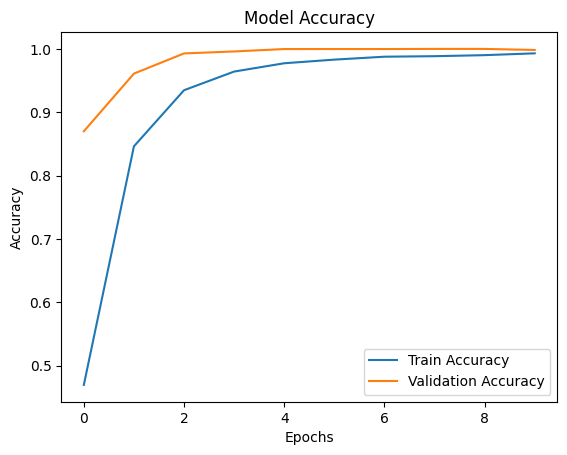

In [14]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [16]:
model.save("gesture_model.keras")